# Sequential Graph
Create multiple nodes that sequentially process and update the state.

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph

In [3]:
# init state dict
class AgentState(TypedDict):
    name: str
    age: str
    final: str

In [18]:
def first_node(state: AgentState) -> AgentState:
    """First node of sequence"""
    state['final'] = f"Hi {state['name']}!"
    return state

def second_node(state: AgentState) -> AgentState:
    """Second node"""
    state['final'] += f" You are {state['age']} years old!"
    return state

In [19]:
graph = StateGraph(AgentState)

graph.add_node('first_node', first_node)
graph.add_node('second_node', second_node)

graph.set_entry_point('first_node')

# NEW: Add edge between first node and second node
graph.add_edge('first_node', 'second_node')     # start point, end point

graph.set_finish_point('second_node')
app = graph.compile()

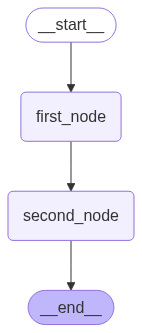

In [20]:
# Display graph
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [21]:
result = app.invoke({"name": "Charlie", "age": 20})
print(result)

{'name': 'Charlie', 'age': 20, 'final': 'Hi Charlie! You are 20 years old!'}


# Exercise 3
Build a 3 node graph that: 1) Personalizes name field with greeting, 2) Describe user's age, 3) List user's skills in a formatted string. Final output in result field should be a combined message. <br>
Input: {"name": "Linda", "age": 31, "skills": ["Python", "Machine Learning", "LangGraph"]} <br>
Output: "Linda, welcome to the system! You are 31 years old! You have skills in: Python, Machine Learning, and LangGraph".

In [27]:
from typing import List
class AgentState(TypedDict):
    name: str
    age: str
    skills: List[str]
    result: str

exercise = StateGraph(AgentState)

In [28]:
def one(state: AgentState) -> AgentState:
    """First node"""
    state['result'] = f"{state['name']}, welcome to the system! "
    return state

def two(state: AgentState) -> AgentState:
    """Second node"""
    state['result'] += f"You are {state['age']} years old! "
    return state

def three(state: AgentState) -> AgentState:
    """Last node"""
    state['result'] += "You have skills in: "
    for index, value in enumerate(state['skills']):
        if index == len(state['skills']) - 1:
            state['result'] += f"and {value}"
        else:
            state['result'] += f"{value}, "
    return state

In [29]:
exercise.add_node('one', one)
exercise.add_node('two', two)
exercise.add_node('three', three)

exercise.set_entry_point('one')
exercise.add_edge('one', 'two')
exercise.add_edge('two', 'three')
exercise.set_finish_point('three')

app = exercise.compile()

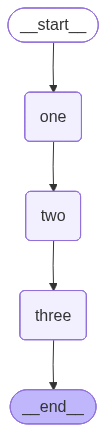

In [30]:
# Display graph
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [32]:
result = app.invoke({"name": "Linda", "age": 31, "skills": ["Python", "Machine Learning", "LangGraph"]})
print(result)
print(result['result'])

{'name': 'Linda', 'age': 31, 'skills': ['Python', 'Machine Learning', 'LangGraph'], 'result': 'Linda, welcome to the system! You are 31 years old! You have skills in: Python, Machine Learning, and LangGraph'}
Linda, welcome to the system! You are 31 years old! You have skills in: Python, Machine Learning, and LangGraph
